Missing values per column:
Calories        0
Protein         0
TotalFat        0
SaturatedFat    0
Carbohydrate    0
Sugar           0
Sodium          0
dtype: int64


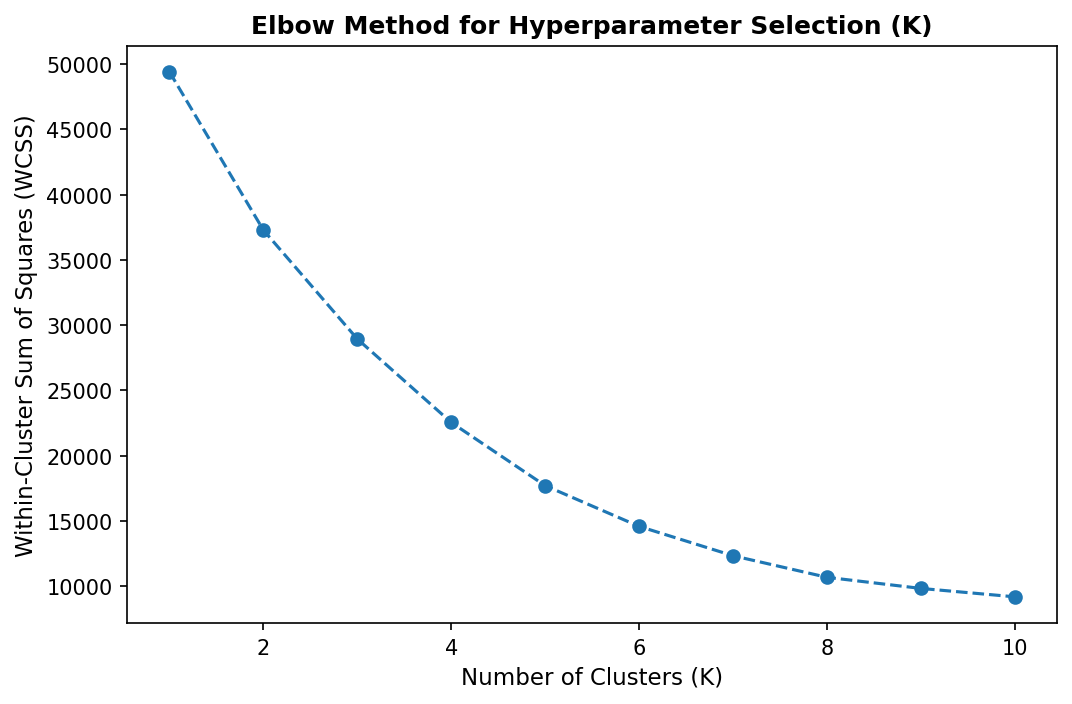

Cluster Sample Distribution (0 = lowest mean Calories, 3 = highest):
Cluster
0    2647
1    2660
2    1523
3     228
Name: count, dtype: int64


Overall Silhouette Score for K=4: 0.4158
Variance explained by PC1 and PC2: 62.35%


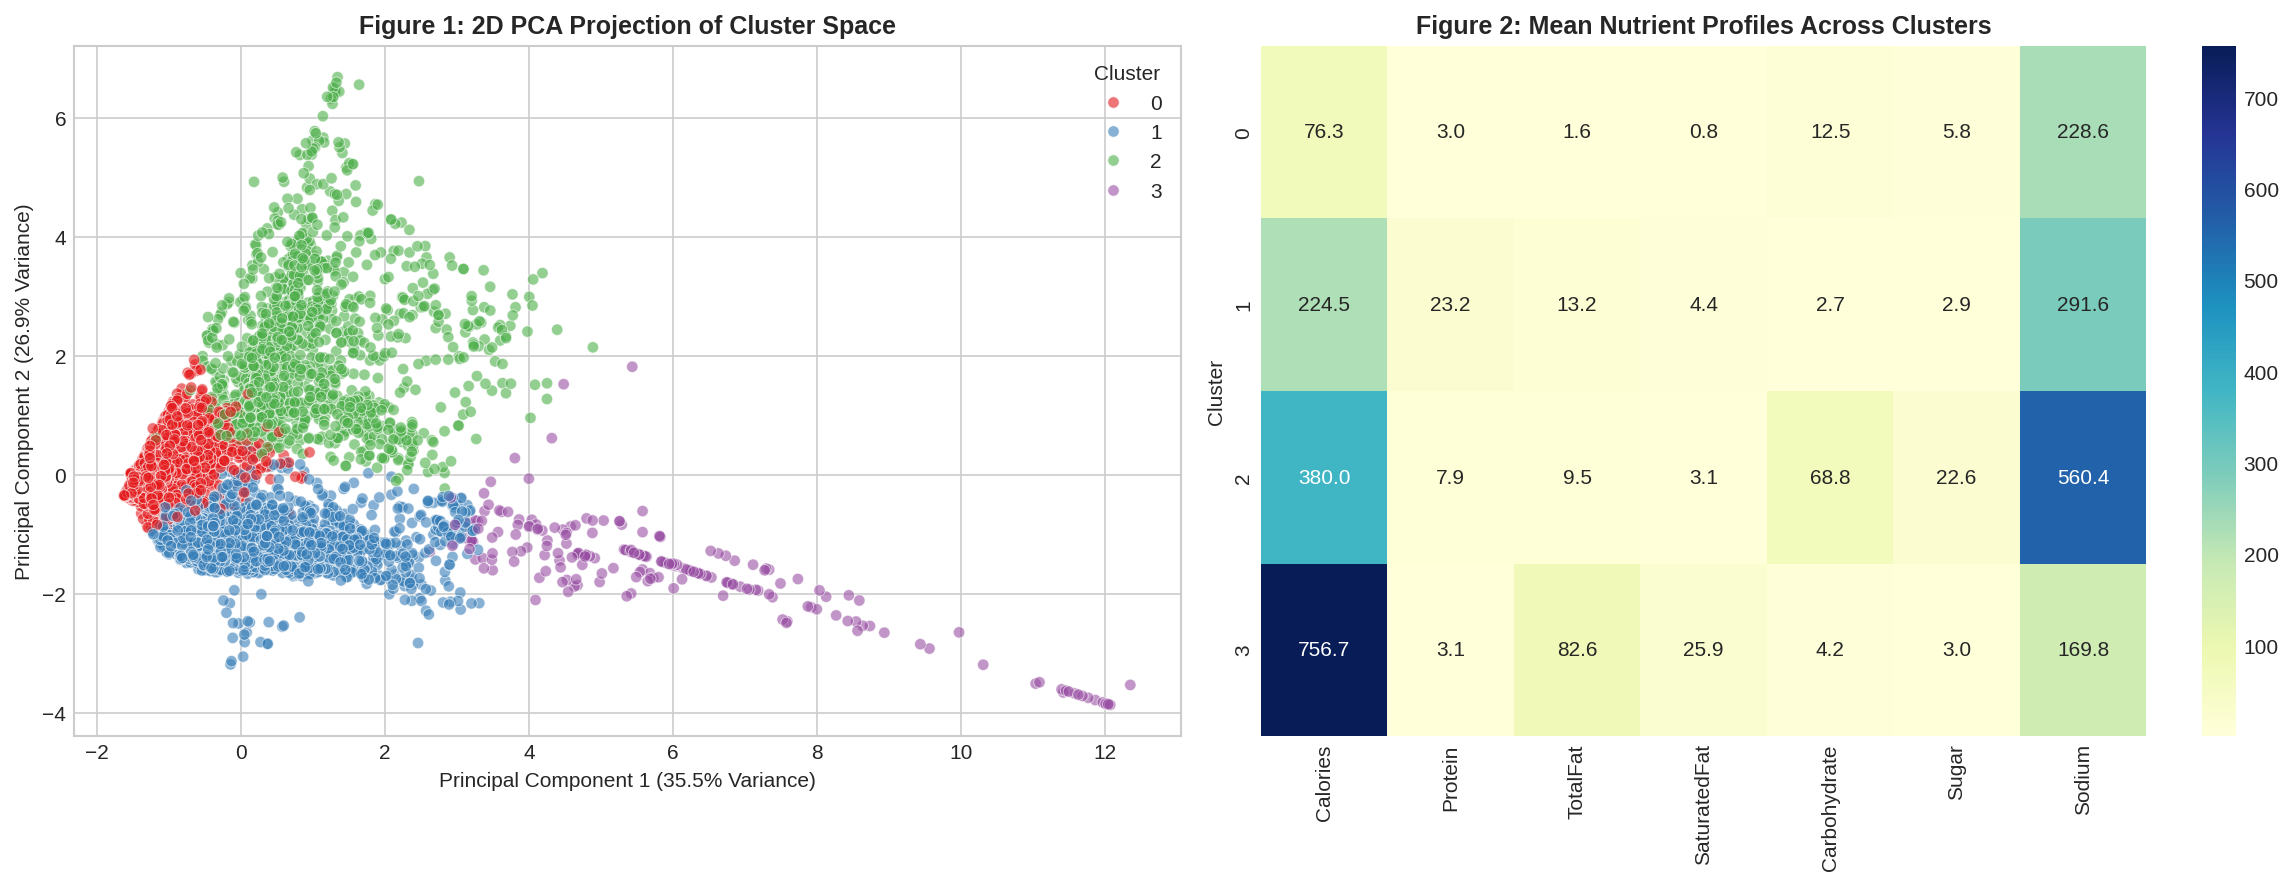

--- HIGH CARBOHYDRATE / SODIUM CLUSTER (Cluster 2) SAMPLE ITEMS ---
4116    COFFEE SUB,RSTD GRAIN BEV,NAT TOUCH KAFFREE RO...
5708                                CANDIES,REESE'S BITES
6906                       GRANOLA BAR,W/COCNT,CHOC COATD
5802                   CANDIES,TAFFY,PREPARED-FROM-RECIPE
5569                               CANDIES,SEMISWEET CHOC
1920    CEREALS,QUAKER,INST OATMEAL,APPL & CINN,RED SUGAR
5395    TOASTER PASTRIES,KELLOGG,KELLOGG'S POP TARTS,S...
6961                                    CEREALS,RTE,ALPEN
5598                             CANDIES,KRACKEL CHOC BAR
5649                              CANDIES,SPL DK CHOC BAR
Name: Description, dtype: str

--- HIGH PROTEIN CLUSTER (Cluster 1) SAMPLE ITEMS ---
4954              LAMB,VAR MEATS&BY-PRODUCTS,PANCREAS,RAW
481             CHICKEN,BROILERS OR FRYERS,MEAT & SKN,RAW
3557                         BEEF,CURED,BRKFST STRIPS,CKD
4347                          SALMON,CHINOOK,CKD,DRY HEAT
3789    BEEF,SHLDR TOP BLADE STEAK,

In [1]:
# ==========================================
# 1. ENVIRONMENT SETUP & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the USDA National Nutrient Database
df = pd.read_csv("USDA.csv")

# Define core nutrient features (7 features per 100g serving)
selected_columns = ['Calories', 'Protein', 'TotalFat', 'SaturatedFat', 'Carbohydrate', 'Sugar', 'Sodium']

# Display initial rows
df[selected_columns].head()


# ==========================================
# 2. MISSING VALUE IMPUTATION
# ==========================================
# Impute missing values across selected features using mean substitution
for col in selected_columns:
    df[col] = df[col].fillna(df[col].mean())

# Verify zero remaining null values
print("Missing values per column:")
print(df[selected_columns].isnull().sum())


# ==========================================
# 3. FEATURE SCALING (Z-SCORE STANDARDIZATION)
# ==========================================
# Initialize StandardScaler to normalize features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[selected_columns])


# ==========================================
# 4. HYPERPARAMETER OPTIMIZATION (ELBOW METHOD)
# ==========================================
# Calculate WCSS for K values from 1 to 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Hyperparameter Selection (K)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
plt.show()


# ==========================================
# 5. MODEL EXECUTION (K=4)
# ==========================================
# Fit K-Means model with optimized hyperparameter K=4
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
raw_labels = kmeans.fit_predict(X_scaled)

# K-Means cluster IDs are arbitrary (they depend on initialization order, not
# meaning). Relabel 0-3 in order of increasing mean Calories so cluster
# numbering is stable and interpretable across reruns and library versions,
# instead of relying on whatever raw ID K-Means happens to assign.
calorie_order = (
    df.assign(_raw=raw_labels)
      .groupby('_raw')['Calories'].mean()
      .sort_values().index
)
relabel_map = {raw_id: new_id for new_id, raw_id in enumerate(calorie_order)}
df['Cluster'] = pd.Series(raw_labels).map(relabel_map).values

# Display item counts per cluster profile
print("Cluster Sample Distribution (0 = lowest mean Calories, 3 = highest):")
print(df['Cluster'].value_counts().sort_index())


# ==========================================
# 6. MODEL EVALUATION & PCA REDUCTION
# ==========================================
# Calculate overall Silhouette Score
sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"Overall Silhouette Score for K=4: {sil_score:.4f}")

# Dimensionality Reduction via PCA (7D -> 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f"Variance explained by PC1 and PC2: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Generate 2-Panel Figure (PCA Scatter Plot & Centroid Heatmap)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: 2D PCA Scatter Plot
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='Cluster', palette='Set1', 
    alpha=0.6, s=30, ax=ax1
)
ax1.set_title('Figure 1: 2D PCA Projection of Cluster Space', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
ax1.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')

# Panel B: Cluster Centroid Heatmap
cluster_means = df.groupby('Cluster')[selected_columns].mean()
sns.heatmap(cluster_means, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True, ax=ax2)
ax2.set_title('Figure 2: Mean Nutrient Profiles Across Clusters', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# 7. CLUSTER SAMPLING & VERIFICATION
# ==========================================
# NOTE: K-Means cluster IDs are arbitrary and not guaranteed to be stable
# across runs/library versions. Rather than hardcoding "Cluster 1" or
# "Cluster 3", identify clusters by their nutrient profile so this cell
# stays correct even if label assignment shifts.
food_column = 'Description'
high_carb_cluster = cluster_means['Carbohydrate'].idxmax()
high_protein_cluster = cluster_means['Protein'].idxmax()

print(f"--- HIGH CARBOHYDRATE / SODIUM CLUSTER (Cluster {high_carb_cluster}) SAMPLE ITEMS ---")
print(df[df['Cluster'] == high_carb_cluster][food_column].sample(10, random_state=42))

print(f"\n--- HIGH PROTEIN CLUSTER (Cluster {high_protein_cluster}) SAMPLE ITEMS ---")
print(df[df['Cluster'] == high_protein_cluster][food_column].sample(10, random_state=42))